# Method 2: Central Node as Switch (CNSw)

## Overview
Root node acts as entanglement swapping hub to create distributed GHZ state.

## Architecture
- **Node 0 (Root)**: Entanglement switch
- **Nodes 1-6**: Clients generating EPR pairs with root

## Phases
1. **EPR Generation**: Each client creates EPR pair with root
2. **GHZ Fusion**: Root swaps entanglement to create GHZ state
3. **Teleportation**: Root performs BSM on data qubit
4. **Broadcast**: Clients apply Pauli corrections

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import math

In [2]:
# Setup: 7 nodes
# Node 0: data qubit + 6 EPR halves + 1 ancilla
# Nodes 1-6: 1 EPR half each

num_clients = 6
data_qubit = 0
root_epr = list(range(1, 1 + num_clients))  # [1,2,3,4,5,6]
ancilla = 7
client_epr = list(range(8, 8 + num_clients))  # [8,9,10,11,12,13]

total_qubits = 1 + num_clients + 1 + num_clients  # 14 qubits
qr = QuantumRegister(total_qubits, 'q')
cr_fusion = ClassicalRegister(num_clients, 'fusion')
cr_bsm = ClassicalRegister(2, 'bsm')
cr_out = ClassicalRegister(num_clients, 'out')
qc = QuantumCircuit(qr, cr_fusion, cr_bsm, cr_out)

print(f"Data qubit: {data_qubit}")
print(f"Root EPR qubits: {root_epr}")
print(f"Ancilla: {ancilla}")
print(f"Client EPR qubits: {client_epr}")

Data qubit: 0
Root EPR qubits: [1, 2, 3, 4, 5, 6]
Ancilla: 7
Client EPR qubits: [8, 9, 10, 11, 12, 13]


In [3]:
# Prepare data qubit
# qc.h(data_qubit)
qc.rx(math.pi / 4, data_qubit)
qc.ry(math.pi / 4, data_qubit)
qc.barrier(label='Data Ready')

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=14, num_clbits=0, params=[]), qubits=(<Qubit register=(14, "q"), index=0>, <Qubit register=(14, "q"), index=1>, <Qubit register=(14, "q"), index=2>, <Qubit register=(14, "q"), index=3>, <Qubit register=(14, "q"), index=4>, <Qubit register=(14, "q"), index=5>, <Qubit register=(14, "q"), index=6>, <Qubit register=(14, "q"), index=7>, <Qubit register=(14, "q"), index=8>, <Qubit register=(14, "q"), index=9>, <Qubit register=(14, "q"), index=10>, <Qubit register=(14, "q"), index=11>, <Qubit register=(14, "q"), index=12>, <Qubit register=(14, "q"), index=13>), clbits=())

In [4]:
# Phase 1: EPR Generation
# Each client creates EPR pair with root

for i in range(num_clients):
    qc.h(root_epr[i])
    qc.cx(root_epr[i], client_epr[i])

qc.barrier(label='EPR Pairs Created')

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=14, num_clbits=0, params=[]), qubits=(<Qubit register=(14, "q"), index=0>, <Qubit register=(14, "q"), index=1>, <Qubit register=(14, "q"), index=2>, <Qubit register=(14, "q"), index=3>, <Qubit register=(14, "q"), index=4>, <Qubit register=(14, "q"), index=5>, <Qubit register=(14, "q"), index=6>, <Qubit register=(14, "q"), index=7>, <Qubit register=(14, "q"), index=8>, <Qubit register=(14, "q"), index=9>, <Qubit register=(14, "q"), index=10>, <Qubit register=(14, "q"), index=11>, <Qubit register=(14, "q"), index=12>, <Qubit register=(14, "q"), index=13>), clbits=())

In [5]:
# Phase 2: GHZ Fusion at Root
# Root prepares ancilla in |+⟩ and fuses EPR halves

qc.h(ancilla)

# Apply CNOTs from ancilla to all root EPR qubits
for i in range(num_clients):
    qc.cx(ancilla, root_epr[i])

# Measure root EPR qubits in Z-basis
for i in range(num_clients):
    qc.measure(root_epr[i], cr_fusion[i])

qc.barrier(label='Fusion Done')

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=14, num_clbits=0, params=[]), qubits=(<Qubit register=(14, "q"), index=0>, <Qubit register=(14, "q"), index=1>, <Qubit register=(14, "q"), index=2>, <Qubit register=(14, "q"), index=3>, <Qubit register=(14, "q"), index=4>, <Qubit register=(14, "q"), index=5>, <Qubit register=(14, "q"), index=6>, <Qubit register=(14, "q"), index=7>, <Qubit register=(14, "q"), index=8>, <Qubit register=(14, "q"), index=9>, <Qubit register=(14, "q"), index=10>, <Qubit register=(14, "q"), index=11>, <Qubit register=(14, "q"), index=12>, <Qubit register=(14, "q"), index=13>), clbits=())

In [6]:
# Clients apply Z corrections based on fusion results
for i in range(num_clients):
    with qc.if_test((cr_fusion[i], 1)):
        qc.x(client_epr[i])

qc.barrier(label='GHZ Established')

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=14, num_clbits=0, params=[]), qubits=(<Qubit register=(14, "q"), index=0>, <Qubit register=(14, "q"), index=1>, <Qubit register=(14, "q"), index=2>, <Qubit register=(14, "q"), index=3>, <Qubit register=(14, "q"), index=4>, <Qubit register=(14, "q"), index=5>, <Qubit register=(14, "q"), index=6>, <Qubit register=(14, "q"), index=7>, <Qubit register=(14, "q"), index=8>, <Qubit register=(14, "q"), index=9>, <Qubit register=(14, "q"), index=10>, <Qubit register=(14, "q"), index=11>, <Qubit register=(14, "q"), index=12>, <Qubit register=(14, "q"), index=13>), clbits=())

In [7]:
# Phase 3: Teleportation
# Root performs BSM between data qubit and ancilla (GHZ qubit)

qc.cx(data_qubit, ancilla)
qc.h(data_qubit)
qc.measure(data_qubit, cr_bsm[0])
qc.measure(ancilla, cr_bsm[1])

qc.barrier(label='BSM Done')

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=14, num_clbits=0, params=[]), qubits=(<Qubit register=(14, "q"), index=0>, <Qubit register=(14, "q"), index=1>, <Qubit register=(14, "q"), index=2>, <Qubit register=(14, "q"), index=3>, <Qubit register=(14, "q"), index=4>, <Qubit register=(14, "q"), index=5>, <Qubit register=(14, "q"), index=6>, <Qubit register=(14, "q"), index=7>, <Qubit register=(14, "q"), index=8>, <Qubit register=(14, "q"), index=9>, <Qubit register=(14, "q"), index=10>, <Qubit register=(14, "q"), index=11>, <Qubit register=(14, "q"), index=12>, <Qubit register=(14, "q"), index=13>), clbits=())

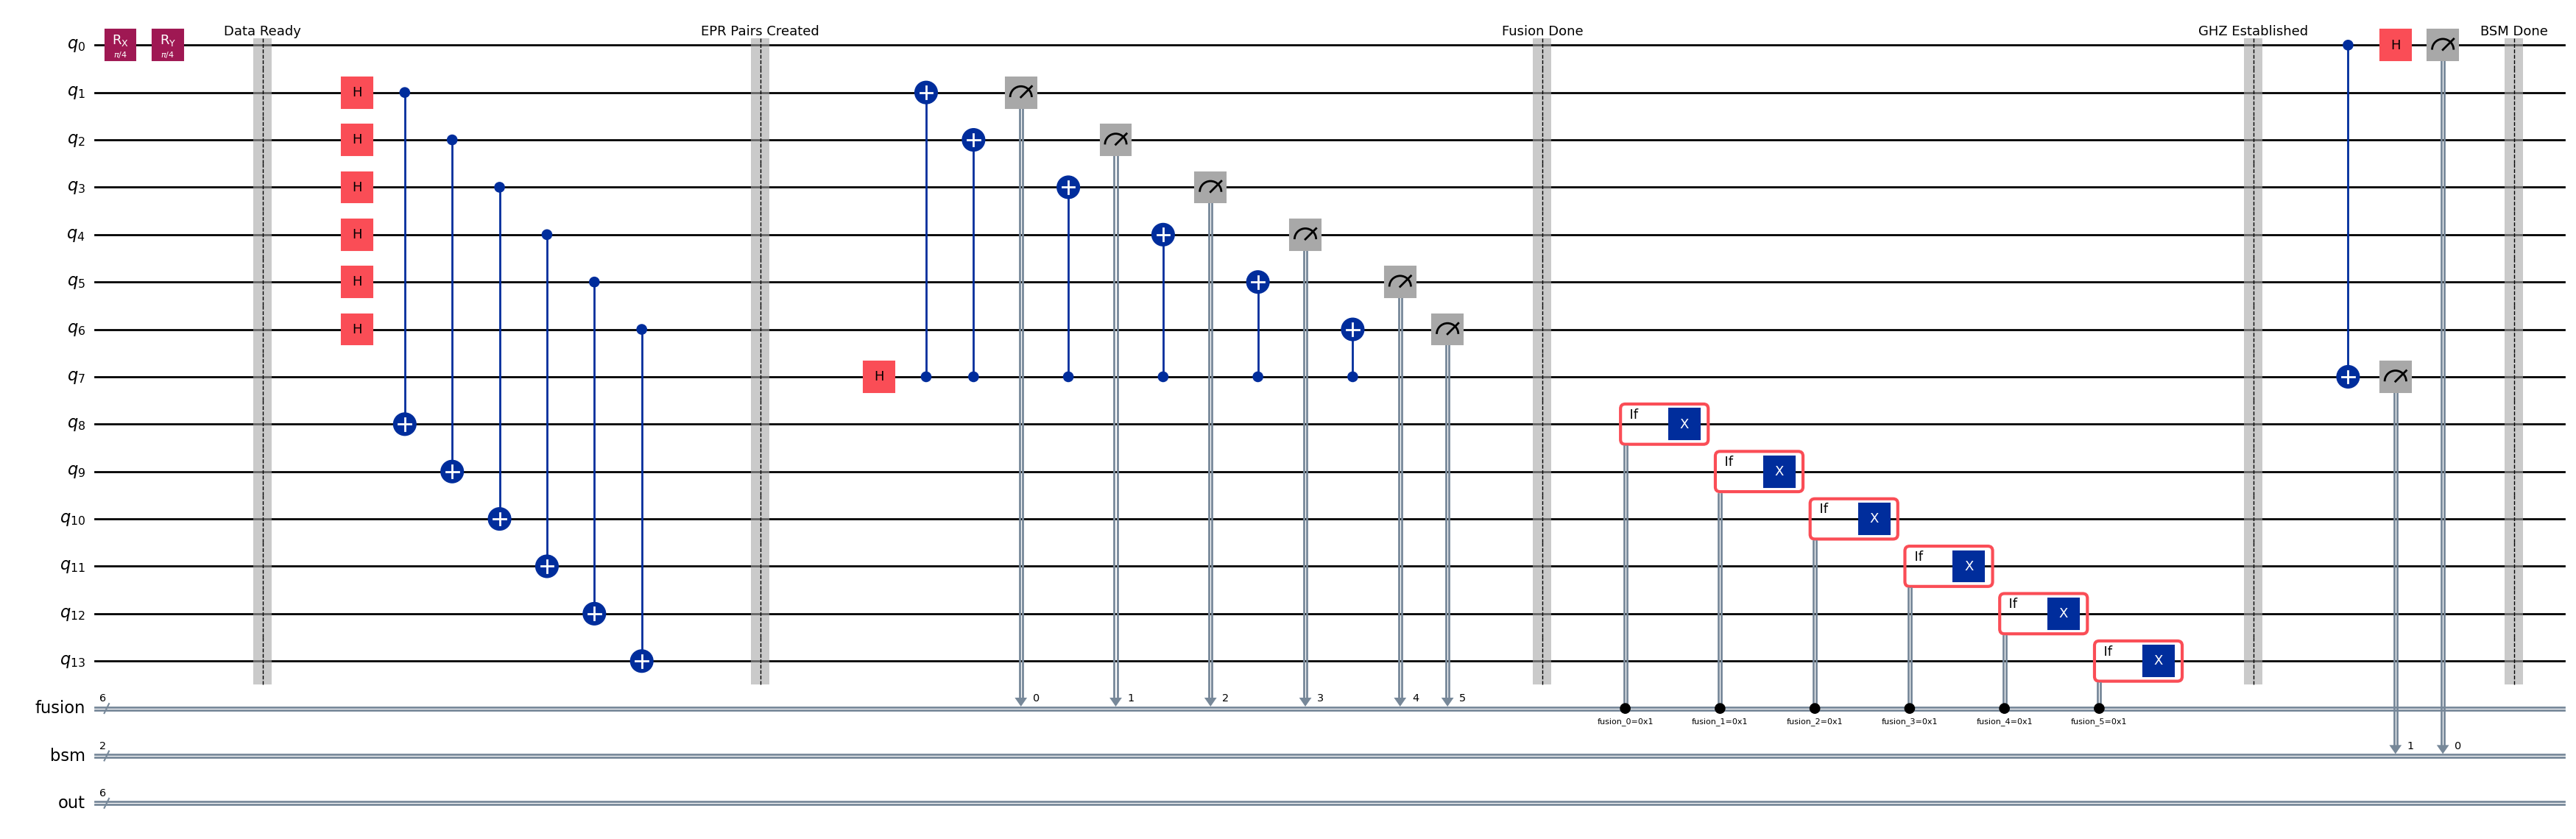

In [8]:
qc.draw('mpl', fold=-1)

In [9]:
# Clients apply Pauli corrections
for i in range(num_clients):
    with qc.if_test((cr_bsm[1], 1)):
        qc.x(client_epr[i])
    with qc.if_test((cr_bsm[0], 1)):
        qc.z(client_epr[i])

qc.barrier(label='Broadcast Complete')

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=14, num_clbits=0, params=[]), qubits=(<Qubit register=(14, "q"), index=0>, <Qubit register=(14, "q"), index=1>, <Qubit register=(14, "q"), index=2>, <Qubit register=(14, "q"), index=3>, <Qubit register=(14, "q"), index=4>, <Qubit register=(14, "q"), index=5>, <Qubit register=(14, "q"), index=6>, <Qubit register=(14, "q"), index=7>, <Qubit register=(14, "q"), index=8>, <Qubit register=(14, "q"), index=9>, <Qubit register=(14, "q"), index=10>, <Qubit register=(14, "q"), index=11>, <Qubit register=(14, "q"), index=12>, <Qubit register=(14, "q"), index=13>), clbits=())

In [10]:
qc.barrier(label='Clean Up (Unitary Reversal)')

# 1. คลีน root_epr ทั้งหมดให้กลับเป็น |0>
for i in range(num_clients):
    with qc.if_test((cr_fusion[i], 1)):
        qc.x(root_epr[i])

qc.barrier(label='All Garbage is |0>')

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=14, num_clbits=0, params=[]), qubits=(<Qubit register=(14, "q"), index=0>, <Qubit register=(14, "q"), index=1>, <Qubit register=(14, "q"), index=2>, <Qubit register=(14, "q"), index=3>, <Qubit register=(14, "q"), index=4>, <Qubit register=(14, "q"), index=5>, <Qubit register=(14, "q"), index=6>, <Qubit register=(14, "q"), index=7>, <Qubit register=(14, "q"), index=8>, <Qubit register=(14, "q"), index=9>, <Qubit register=(14, "q"), index=10>, <Qubit register=(14, "q"), index=11>, <Qubit register=(14, "q"), index=12>, <Qubit register=(14, "q"), index=13>), clbits=())

In [11]:
# Measure client qubits
for i in range(num_clients):
    qc.measure(client_epr[i], cr_out[i])

print(f"Circuit depth: {qc.depth()}")
print(f"Circuit size: {qc.size()}")

Circuit depth: 25
Circuit size: 61


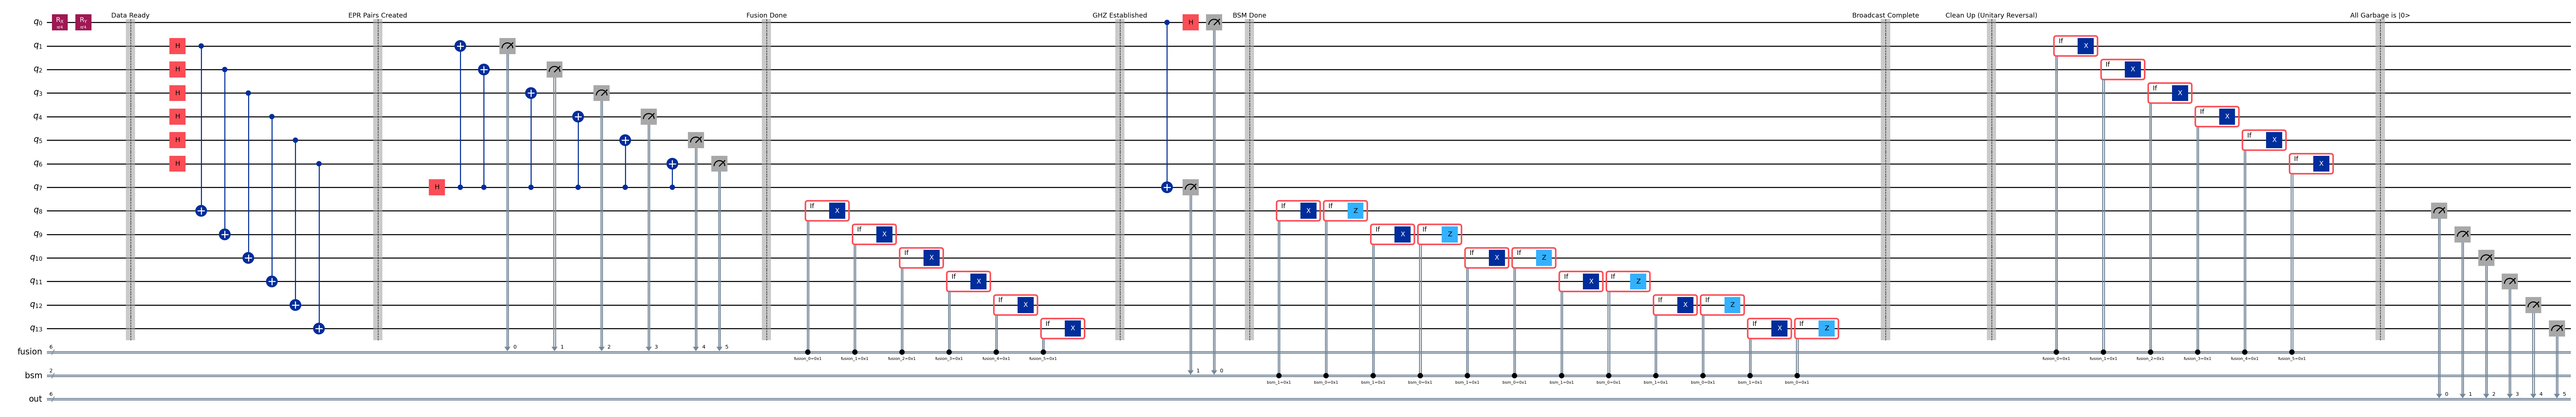

In [12]:
qc.draw('mpl', fold=-1)

In [13]:
# # Simulate
# backend = AerSimulator()
# job = backend.run(qc, shots=1024)
# result = job.result()
# counts = result.get_counts()

# plot_histogram(counts, figsize=(15, 6))

In [14]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.quantum_info import Statevector
import numpy as np

# 1 ลบการวัดออก (เพื่อดูสถานะก่อน collapse)
circ_no_measure = qc.remove_final_measurements(inplace=False)

# 2 บอกให้ simulator เก็บ statevector
circ_no_measure.save_statevector() 

# 3 ใช้ simulator แบบ statevector
sim_sv = AerSimulator(method='statevector')

# 4 transpile และรัน
ready_sv = transpile(circ_no_measure, sim_sv)
result_sv = sim_sv.run(ready_sv).result()

# 5 ดึงข้อมูล statevector ออกมา
statevector = result_sv.data(0)['statevector']
# print(statevector)

# statevector จากผล simulation
vec = Statevector(statevector)

# แสดงเฉพาะค่าสำคัญ
for i, amp in enumerate(vec.data):
    if not np.isclose(abs(amp), 0):  # ข้ามค่าที่แทบเป็นศูนย์
        print(f"|{i:0{vec.num_qubits}b}> : {amp}")

|00000010000000> : (0.8535533905932736+0.14644660940672624j)
|11111110000000> : (0.35355339059327373-0.3535533905932738j)


In [14]:
import pandas as pd
from qiskit import transpile

# นำเข้า Fake Backends จาก qiskit_ibm_runtime (หรือ qiskit.providers.fake_provider สำหรับเวอร์ชั่นเก่า)
from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeBrisbane, FakeKawasaki, FakeTorino, FakePeekskill

# 1. กำหนดตัวแปร Circuit ของคุณ
qc = qc

# 2. เตรียม Backend ทั้ง 5 ตัวตามที่ระบุ
backends = {
    "fake_auckland": FakeAuckland(),
    "fake_brisbane": FakeBrisbane(),
    "fake_kawasaki": FakeKawasaki(),
    "fake_torino": FakeTorino(),
    "fake_peekskill": FakePeekskill()
}

results = []

print(f"🚀 เริ่มต้น Benchmark วงจรขนาด {qc.num_qubits} Qubits...")
print("-" * 50)

# 3. วนลูป Transpile ระดับ 3 และคำนวณ CD, EN, PC
for name, backend in backends.items():
    print(f"⏳ กำลัง Transpile ลงบน {name}...", end=" ")
    
    try:
        # สั่ง Transpile ที่ระดับ 3 (ไม่สนใจ Error ตามที่บอก)
        transpiled_qc = transpile(qc, backend=backend, optimization_level=3)
        
        # --- คำนวณ Metrics ---
        # 1. CD: Circuit Depth (ความลึกของวงจร)
        cd = transpiled_qc.depth()
        
        # 2. EN: Entangling Gates (จำนวน 2-qubit gates ที่แสดงถึงการเชื่อมต่อ/Entanglement)
        en = transpiled_qc.num_nonlocal_gates() 
        
        # 3. PC: Program Communication (สัดส่วนของเกตเชื่อมต่อเทียบกับเกตทั้งหมด)
        total_gates = sum(transpiled_qc.count_ops().values())
        pc = en / total_gates if total_gates > 0 else 0
        
        results.append({
            "Backend": name,
            "CD": cd,
            "EN": en,
            "PC": round(pc, 4)  # ปัดเศษให้สวยงาม
        })
        print("✅ เสร็จสิ้น")
        
    except Exception as e:
        print(f"❌ ล้มเหลว ({str(e)})")
        results.append({
            "Backend": name,
            "CD": "Error",
            "EN": "Error",
            "PC": "Error"
        })

# 4. แสดงผลลัพธ์เป็นตาราง
df_results = pd.DataFrame(results)

🚀 เริ่มต้น Benchmark วงจรขนาด 14 Qubits...
--------------------------------------------------
⏳ กำลัง Transpile ลงบน fake_auckland... ✅ เสร็จสิ้น
⏳ กำลัง Transpile ลงบน fake_brisbane... ✅ เสร็จสิ้น
⏳ กำลัง Transpile ลงบน fake_kawasaki... ✅ เสร็จสิ้น
⏳ กำลัง Transpile ลงบน fake_torino... ✅ เสร็จสิ้น
⏳ กำลัง Transpile ลงบน fake_peekskill... ✅ เสร็จสิ้น


In [15]:
df_results

,Backend,CD,EN,PC
0,fake_auckland,60,37,0.3033
1,fake_brisbane,127,37,0.1131
2,fake_kawasaki,125,40,0.1198
3,fake_torino,83,37,0.1595
4,fake_peekskill,111,31,0.1080


In [18]:
# Analysis
print("\n=== Broadcast Results ===")
print(f"Expected: All clients receive same state via entanglement swapping")
print(f"\nTop 10 outcomes:")
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10]
for state, count in sorted_counts:
    print(f"{state}: {count} ({100*count/1024:.1f}%)")


=== Broadcast Results ===
Expected: All clients receive same state via entanglement swapping

Top 10 outcomes:
011111 00 010101: 3 (0.3%)
010010 11 000111: 2 (0.2%)
010100 11 111001: 2 (0.2%)
110011 10 001011: 2 (0.2%)
101101 00 011001: 2 (0.2%)
001101 00 111001: 2 (0.2%)
110101 10 101000: 2 (0.2%)
100100 11 101011: 2 (0.2%)
101110 00 111101: 2 (0.2%)
101111 00 111101: 2 (0.2%)


## Results

- Root acts as entanglement switch, not source
- Clients generate EPR pairs with root
- Root fuses EPR halves into distributed GHZ state
- Broadcast achieved via teleportation over GHZ state
- Requires 6 fusion bits + 2 BSM bits = 8 classical bits total

In [18]:
from supermarq import *
import supermarq.converters as converters
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister

sim = AerSimulator()
star_topology_sequence = transpile(qc, backend=sim, optimization_level=3)

bcast_tinthai = [
    features.compute_communication_with_qiskit(star_topology_sequence),
    features.compute_depth_with_qiskit(star_topology_sequence),
    features.compute_entanglement_with_qiskit(star_topology_sequence)
]

print("Metrics calculated successfully!")
print(f"Communication: {bcast_tinthai[0]}")
print(f"Depth: {bcast_tinthai[1]}")
print(f"Entanglement: {bcast_tinthai[2]}")

Metrics calculated successfully!
Communication: 0.14285714285714285
Depth: 0.6153846153846154
Entanglement: 0.5909090909090909
